# Import Dependencies

Sets up environment for baseline time series models.
Imports libraries for ARIMA and LSTM implementations with evaluation metrics.

Core imports:
- numpy, pandas: Data manipulation
- torch: LSTM implementation
- sklearn: Metrics and preprocessing
- statsmodels: ARIMA and time series tools
- pmdarima: Automated ARIMA parameter selection
- matplotlib/seaborn: Plotting results
- tqdm: Training progress bars

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import pickle
import time
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Any
import warnings
from tqdm import tqdm
import logging

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ARIMABaseline - Statistical Time Series Model

Implements ARIMA forecasting for network traffic data.
Uses auto_arima to find best (p,d,q) parameters automatically.

Configuration:
- max_p, max_q: Upper bounds for AR and MA terms (default 5)
- max_d: Maximum differencing degree (default 2)
- validation_split: Train/test split ratio (0.2)

Key methods:
- check_stationarity(): Runs ADF test, handles constant series
- find_best_params(): Uses pmdarima auto_arima for parameter selection
- train(): Fits ARIMA model, performs walk-forward validation
- predict(): Generates future forecasts
- plot_results(): Creates prediction vs actual plots

Training process:
- Scales data with StandardScaler
- Finds optimal ARIMA order
- Walk-forward validation (updates model at each step)
- Computes MAE, RMSE, R², MAPE metrics

In [2]:
class ARIMABaseline:
    """
    ARIMA baseline model for time series forecasting and automatically identifies optimal parameters and handles non stationary data
    """
    
    def __init__(self, config: Optional[Dict[str, Any]] = None):
        self.config = config or self.get_default_config()
        self.models = {}
        self.scalers = {}
        self.history = {}
        self.metrics = {}
        
    def get_default_config(self) -> Dict[str, Any]:
        """Default ARIMA configuration with auto-tuning parameters """
        return {
            'max_p': 5,
            'max_d': 2,
            'max_q': 5,
            'seasonal': False,
            'stepwise': True,
            'suppress_warnings': True,
            'error_action': 'ignore',
            'trace': False,
            'n_jobs': -1,
            'forecast_horizon': 1,
            'validation_split': 0.2
        }
    
    def check_stationarity(self, series: pd.Series, name: str = "Series") -> Dict[str, Any]:
        """Handles edge case of constant series """
        try:
            result = adfuller(series.dropna())
            
            stats = {
                'adf_statistic': result[0],
                'p_value': result[1],
                'critical_values': result[4],
                'is_stationary': result[1] < 0.05
            }
            
            logger.info(f"Stationarity test for {name}:")
            logger.info(f"  ADF Statistic: {stats['adf_statistic']:.4f}")
            logger.info(f"  p-value: {stats['p_value']:.4f}")
            logger.info(f"  Stationary: {stats['is_stationary']}")
            
            return stats
            
        except ValueError as e:
            # Handle constant series where ADF test is undefined
            if "constant" in str(e).lower():
                logger.warning(f"Constant series detected for {name} - cannot perform ADF test")
                return {
                    'adf_statistic': np.nan,
                    'p_value': 1.0,  
                    'critical_values': {},
                    'is_stationary': False,
                    'error': 'Constant series'
                }
            else:
                raise e
    
    def find_best_params(self, series: pd.Series, name: str = "target") -> Tuple[int, int, int]:
        """
        Use auto ARIMA to find optimal (p,d,q) parameters it falls back to conservative defaults if auto selection fails
        """
        logger.info(f"Finding best ARIMA parameters for {name}...")
        
        try:
            model = pm.auto_arima(
                series,
                start_p=0, start_q=0,
                max_p=self.config['max_p'],
                max_q=self.config['max_q'],
                max_d=self.config['max_d'],
                seasonal=self.config['seasonal'],
                stepwise=self.config['stepwise'],  # Stepwise search for efficiency
                suppress_warnings=self.config['suppress_warnings'],
                error_action=self.config['error_action'],
                trace=self.config['trace'],
                n_jobs=self.config['n_jobs'],
                test='adf',
                d=None,
                start_d=0,
                max_order=10
            )
            
            order = model.order
            logger.info(f"  Best parameters for {name}: ARIMA{order}")
            logger.info(f"  AIC: {model.aic():.2f}")
            
            return order
            
        except Exception as e:
            logger.warning(f"Auto ARIMA failed for {name}: {e}")
            logger.info("  Falling back to ARIMA(2,0,2)")
            return (2, 0, 2)
    
    def train(self, data_path: str, target_columns: Optional[List[str]] = None) -> Dict[str, Any]:
        """Train ARIMA models on specified target columns """
        logger.info("="*60)
        logger.info("TRAINING ARIMA BASELINE")
        logger.info("="*60)
        
        df = pd.read_csv(data_path)
        if 'datetime' in df.columns:
            df['datetime'] = pd.to_datetime(df['datetime'])
            df.set_index('datetime', inplace=True)
        
        # Auto detect target columns if not specified
        if target_columns is None:
            target_columns = ['packet_count_sum', 'total_bytes_sum']
            target_columns = [col for col in target_columns if col in df.columns]
            
            if not target_columns:
                numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
                target_columns = numeric_cols[:2] if len(numeric_cols) >= 2 else numeric_cols
        
        logger.info(f"Data shape: {df.shape}")
        logger.info(f"Target columns: {target_columns}")
        
        split_idx = int(len(df) * (1 - self.config['validation_split']))
        train_data = df.iloc[:split_idx]
        val_data = df.iloc[split_idx:]
        
        logger.info(f"Train samples: {len(train_data)}")
        logger.info(f"Validation samples: {len(val_data)}")
        
        results = {}
        
        for target_col in target_columns:
            if target_col not in df.columns:
                logger.warning(f"Column {target_col} not found in data")
                continue
                
            logger.info(f"\nTraining ARIMA for {target_col}")
            logger.info("-"*40)
            
            train_series = train_data[target_col]
            val_series = val_data[target_col]
            
            # Normalize data for numerical stability
            scaler = StandardScaler()
            train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1)).flatten()
            val_scaled = scaler.transform(val_series.values.reshape(-1, 1)).flatten()
            
            self.scalers[target_col] = scaler
            
            stationarity = self.check_stationarity(pd.Series(train_scaled), target_col)
            
            best_order = self.find_best_params(pd.Series(train_scaled), target_col)
            
            try:
                start_time = time.time()
                
                # Initial model fitting
                model = ARIMA(train_scaled, order=best_order)
                fitted_model = model.fit()
                
                train_time = time.time() - start_time
                
                self.models[target_col] = fitted_model
                
                # Walk forward validation
                predictions_scaled = []
                history = list(train_scaled)
                
                for i in range(len(val_scaled)):
                    model = ARIMA(history, order=best_order)
                    model_fit = model.fit()
                    
                    yhat = model_fit.forecast(steps=1)[0]
                    predictions_scaled.append(yhat)
                    
                    # Update history with actual value
                    history.append(val_scaled[i])
                
                predictions_scaled = np.array(predictions_scaled)
                
                # Inverse transform predictions
                predictions = scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
                actual = val_series.values
                
                # Calculates metrics
                mae = mean_absolute_error(actual, predictions)
                rmse = np.sqrt(mean_squared_error(actual, predictions))
                r2 = r2_score(actual, predictions)
                
                # Symmetric MAPE for handling zeros
                if not (actual == 0).any():
                    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
                else:
                    mape = np.mean(2 * np.abs(actual - predictions) / (np.abs(actual) + np.abs(predictions) + 1e-10)) * 100
                
                results[target_col] = {
                    'order': best_order,
                    'aic': fitted_model.aic,
                    'bic': fitted_model.bic,
                    'mae': mae,
                    'rmse': rmse,
                    'r2': r2,
                    'mape': mape,
                    'train_time': train_time,
                    'predictions': predictions,
                    'actual': actual,
                    'stationarity': stationarity
                }
                
                logger.info(f"  ARIMA{best_order} Results:")
                logger.info(f"    MAE: {mae:.4f}")
                logger.info(f"    RMSE: {rmse:.4f}")
                logger.info(f"    R²: {r2:.4f}")
                logger.info(f"    MAPE: {mape:.2f}%")
                logger.info(f"    Training time: {train_time:.2f}s")
                
            except Exception as e:
                logger.error(f"Failed to train ARIMA for {target_col}: {e}")
                results[target_col] = {'error': str(e)}
        
        self.metrics = results
        return results
    
    def predict(self, steps: int = 10) -> Dict[str, np.ndarray]:
        """Generates future predictions for all trained models """
        predictions = {}
        
        for target_col, model in self.models.items():
            try:
                pred_scaled = model.forecast(steps=steps)
                
                scaler = self.scalers[target_col]
                pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
                
                predictions[target_col] = pred
                
            except Exception as e:
                logger.error(f"Prediction failed for {target_col}: {e}")
                predictions[target_col] = np.array([])
        
        return predictions
    
    def plot_results(self, save_path: Optional[str] = None):
        """Creating diagnostic plots for ARIMA model performance"""
        n_targets = len(self.metrics)
        fig, axes = plt.subplots(n_targets, 2, figsize=(15, 5*n_targets))
        
        if n_targets == 1:
            axes = axes.reshape(1, -1)
        
        for idx, (target_col, results) in enumerate(self.metrics.items()):
            if 'error' in results:
                continue
                
            actual = results['actual']
            predictions = results['predictions']
            
            # Time series plot
            ax1 = axes[idx, 0]
            ax1.plot(actual, label='Actual', alpha=0.7)
            ax1.plot(predictions, label='Predicted', alpha=0.7)
            ax1.set_title(f'ARIMA Predictions - {target_col}')
            ax1.set_xlabel('Time Step')
            ax1.set_ylabel('Value')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            # Scatter plot with ideal line
            ax2 = axes[idx, 1]
            ax2.scatter(actual, predictions, alpha=0.5)
            ax2.plot([actual.min(), actual.max()], 
                    [actual.min(), actual.max()], 
                    'r--', lw=2)
            ax2.set_title(f'Actual vs Predicted - {target_col}')
            ax2.set_xlabel('Actual')
            ax2.set_ylabel('Predicted')
            ax2.grid(True, alpha=0.3)
            
            # Add metrics annotation
            metrics_text = f"MAE: {results['mae']:.4f}\nRMSE: {results['rmse']:.4f}\nR²: {results['r2']:.4f}"
            ax2.text(0.05, 0.95, metrics_text, transform=ax2.transAxes,
                    verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.5))
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            logger.info(f"Plot saved to {save_path}")
        
        plt.show()

# LSTMModel - Neural Network for Sequences

Defines LSTM architecture for time series prediction.

Architecture:
- LSTM layers: 2 stacked layers with 128 hidden units
- Dropout: 0.2 between layers
- Output network: Hidden → Hidden/2 → Output
- Activation: ReLU

Forward pass:
- Processes sequence through LSTM
- Takes last timestep output
- Applies dropout and feed-forward layers
- Returns predictions

In [3]:
class LSTMModel(nn.Module):
    """LSTM neural network for multivariate time series prediction """
    
    def __init__(self, input_size: int, hidden_size: int = 128, 
                 num_layers: int = 2, output_size: int = 2, 
                 dropout: float = 0.2):
        super(LSTMModel, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0  # Dropout only between layers
        )
        
        self.dropout = nn.Dropout(dropout)
        
        # Two-layer output network
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, output_size)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Use last timestep output
        out = lstm_out[:, -1, :]
        
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

# LSTMBaseline - LSTM Training Pipeline

Manages LSTM training, validation, and evaluation.

Data preparation:
- Loads sequences and labels from NPZ files
- Handles 1D/2D/3D label shapes
- Scales labels with StandardScaler
- Creates train/validation split (80/20)
- Builds PyTorch DataLoaders

Training configuration:
- Adam optimizer with weight decay
- ReduceLROnPlateau scheduler
- MSE loss function
- Gradient clipping (max norm 1.0)
- Early stopping with patience

Training loop:
- Trains for up to 100 epochs
- Validates every epoch
- Tracks train/val losses and metrics
- Saves best model based on validation loss
- Stops early if no improvement

Methods:
- prepare_data(): Loads and preprocesses sequences
- train(): Main training loop with validation
- predict(): Inference on new sequences
- plot_results(): 4-panel training visualization
- save_model()/load_model(): Model persistence

In [4]:
class LSTMBaseline:
    """LSTM baseline for time series forecasting with early stopping and learning rate scheduling """
    
    def __init__(self, config: Optional[Dict[str, Any]] = None):
        self.config = config or self.get_default_config()
        self.model = None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.history = {'train_loss': [], 'val_loss': [], 'val_mae': [], 'val_rmse': []}
        self.metrics = {}
        self.scaler = StandardScaler()
        self.actual_output_size = None
        
    def get_default_config(self) -> Dict[str, Any]:
        """Default LSTM configuration with regularization parameters """
        return {
            'hidden_size': 128,
            'num_layers': 2,
            'dropout': 0.2,
            'learning_rate': 0.001,
            'batch_size': 32,
            'num_epochs': 100,
            'patience': 15,
            'min_delta': 0.0001,
            'weight_decay': 1e-5,
            'gradient_clip': 1.0,
            'validation_split': 0.2,
            'shuffle': True   
        }
    
    def prepare_data(self, data_path: str) -> Tuple[DataLoader, DataLoader, Dict]:
        """ Loads and prepares LSTM sequences, handling various label formats"""
        logger.info("Loading preprocessed LSTM data...")
        
        data = np.load(data_path)
        sequences = data['sequences']
        labels = data['labels']
        
        logger.info(f"Original sequences shape: {sequences.shape}")
        logger.info(f"Original labels shape: {labels.shape}")
        
        # Handle different label dimensions
        if len(labels.shape) == 3:
            labels = labels[:, 0, :]  # Take first timestep for many-to-one
            logger.info(f"Reshaped labels from 3D to 2D: {labels.shape}")
        elif len(labels.shape) == 1:
            labels = labels.reshape(-1, 1)
            logger.info(f"Reshaped labels from 1D to 2D: {labels.shape}")
        
        self.actual_output_size = labels.shape[1] if len(labels.shape) > 1 else 1
        logger.info(f"Actual output size: {self.actual_output_size}")
        
        metadata = {
            'sequence_shape': sequences.shape,
            'label_shape': labels.shape,
            'feature_names': data.get('feature_names', []),
            'target_names': data.get('target_names', [])
        }
        
        n_samples = len(sequences)
        n_train = int(n_samples * (1 - self.config.get('validation_split', 0.2)))
        
        # Optional shuffling for better generalization
        if self.config.get('shuffle', True):
            indices = np.random.permutation(n_samples)
            sequences = sequences[indices]
            labels = labels[indices]
        
        # Split data
        X_train = sequences[:n_train]
        y_train = labels[:n_train]
        X_val = sequences[n_train:]
        y_val = labels[n_train:]
        
        # Normalize targets
        y_train_scaled = self.scaler.fit_transform(y_train)
        y_val_scaled = self.scaler.transform(y_val)
        
        logger.info(f"Scaler fitted on shape: {y_train.shape}")
        logger.info(f"Scaled train labels shape: {y_train_scaled.shape}")
        logger.info(f"Scaled val labels shape: {y_val_scaled.shape}")
        
        # Create tensors
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train_scaled)
        X_val_tensor = torch.FloatTensor(X_val)
        y_val_tensor = torch.FloatTensor(y_val_scaled)
        
        # Create datasets and loaders
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.config['batch_size'],
            shuffle=True
        )
        
        val_loader = DataLoader(
            val_dataset,
            batch_size=self.config['batch_size'],
            shuffle=False
        )
        
        logger.info(f"Train samples: {len(X_train)}")
        logger.info(f"Validation samples: {len(X_val)}")
        
        # Store for later use
        self.train_data = (X_train, y_train)
        self.val_data = (X_val, y_val)
        
        return train_loader, val_loader, metadata
    
    def train(self, data_path: str) -> Dict[str, Any]:
        """Train LSTM with early stopping and adaptive learning rate """
        logger.info("="*60)
        logger.info("TRAINING LSTM BASELINE")
        logger.info("="*60)
        
        train_loader, val_loader, metadata = self.prepare_data(data_path)
        
        input_size = metadata['sequence_shape'][2]
        output_size = self.actual_output_size
        
        logger.info(f"Model configuration:")
        logger.info(f"  Input size: {input_size}")
        logger.info(f"  Output size: {output_size}")
        
        # Initialize model
        self.model = LSTMModel(
            input_size=input_size,
            hidden_size=self.config['hidden_size'],
            num_layers=self.config['num_layers'],
            output_size=output_size,
            dropout=self.config['dropout']
        ).to(self.device)
        
        logger.info(f"Model architecture:")
        logger.info(f"  Input size: {input_size}")
        logger.info(f"  Hidden size: {self.config['hidden_size']}")
        logger.info(f"  Num layers: {self.config['num_layers']}")
        logger.info(f"  Output size: {output_size}")
        logger.info(f"  Total parameters: {sum(p.numel() for p in self.model.parameters()):,}")
        
        criterion = nn.MSELoss()
        optimizer = optim.Adam(
            self.model.parameters(),
            lr=self.config['learning_rate'],
            weight_decay=self.config['weight_decay']
        )
        
        # Learning rate scheduler for adaptive training
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )
        
        best_val_loss = float('inf')
        patience_counter = 0
        
        start_time = time.time()
        
        for epoch in range(self.config['num_epochs']):
            # Training phase
            self.model.train()
            train_loss = 0.0
            
            for batch_x, batch_y in train_loader:
                batch_x = batch_x.to(self.device)
                batch_y = batch_y.to(self.device)
                
                outputs = self.model(batch_x)
                loss = criterion(outputs, batch_y)
                
                optimizer.zero_grad()
                loss.backward()
                
                # Gradient clipping for stability
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(), 
                    self.config['gradient_clip']
                )
                
                optimizer.step()
                train_loss += loss.item()
            
            avg_train_loss = train_loss / len(train_loader)
            
            # Validation phase
            self.model.eval()
            val_loss = 0.0
            val_predictions = []
            val_actuals = []
            
            with torch.no_grad():
                for batch_x, batch_y in val_loader:
                    batch_x = batch_x.to(self.device)
                    batch_y = batch_y.to(self.device)
                    
                    outputs = self.model(batch_x)
                    loss = criterion(outputs, batch_y)
                    val_loss += loss.item()
                    
                    val_predictions.append(outputs.cpu().numpy())
                    val_actuals.append(batch_y.cpu().numpy())
            
            avg_val_loss = val_loss / len(val_loader)
            
            # Calculate metrics
            val_predictions = np.vstack(val_predictions)
            val_actuals = np.vstack(val_actuals)
            
            logger.debug(f"Epoch {epoch+1} - Val predictions shape: {val_predictions.shape}")
            logger.debug(f"Epoch {epoch+1} - Val actuals shape: {val_actuals.shape}")
            
            # Inverse transform for real-scale metrics
            val_predictions_orig = self.scaler.inverse_transform(val_predictions)
            val_actuals_orig = self.scaler.inverse_transform(val_actuals)
            
            mae = mean_absolute_error(val_actuals_orig, val_predictions_orig)
            rmse = np.sqrt(mean_squared_error(val_actuals_orig, val_predictions_orig))
            
            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(avg_val_loss)
            self.history['val_mae'].append(mae)
            self.history['val_rmse'].append(rmse)
            
            scheduler.step(avg_val_loss)
            
            # Early stopping logic
            if avg_val_loss < best_val_loss - self.config['min_delta']:
                best_val_loss = avg_val_loss
                patience_counter = 0
                self.best_model_state = self.model.state_dict()
            else:
                patience_counter += 1
            
            # Periodic logging
            if (epoch + 1) % 10 == 0:
                logger.info(f"Epoch [{epoch+1}/{self.config['num_epochs']}]")
                logger.info(f"  Train Loss: {avg_train_loss:.6f}")
                logger.info(f"  Val Loss: {avg_val_loss:.6f}")
                logger.info(f"  Val MAE: {mae:.4f}")
                logger.info(f"  Val RMSE: {rmse:.4f}")
            
            if patience_counter >= self.config['patience']:
                logger.info(f"Early stopping triggered at epoch {epoch+1}")
                break
        
        # Load best model
        if hasattr(self, 'best_model_state'):
            self.model.load_state_dict(self.best_model_state)
        
        training_time = time.time() - start_time
        
        # Final evaluation
        self.model.eval()
        
        X_val, y_val = self.val_data
        X_val_tensor = torch.FloatTensor(X_val).to(self.device)
        
        with torch.no_grad():
            predictions_scaled = self.model(X_val_tensor).cpu().numpy()
        
        logger.info(f"Final predictions shape: {predictions_scaled.shape}")
        logger.info(f"Expected shape for inverse transform: {y_val.shape}")
        
        predictions = self.scaler.inverse_transform(predictions_scaled)
        
        final_mae = mean_absolute_error(y_val, predictions)
        final_rmse = np.sqrt(mean_squared_error(y_val, predictions))
        final_r2 = r2_score(y_val, predictions)
        
        # Benchmark inference speed
        inference_times = []
        for _ in range(100):
            start = time.time()
            with torch.no_grad():
                _ = self.model(X_val_tensor[:1])
            inference_times.append(time.time() - start)
        
        avg_inference_time = np.mean(inference_times) * 1000
        
        self.metrics = {
            'final_mae': final_mae,
            'final_rmse': final_rmse,
            'final_r2': final_r2,
            'best_val_loss': best_val_loss,
            'training_time': training_time,
            'avg_inference_time_ms': avg_inference_time,
            'total_epochs': epoch + 1,
            'model_parameters': sum(p.numel() for p in self.model.parameters()),
            'predictions': predictions,
            'actual': y_val
        }
        
        logger.info("\n" + "="*60)
        logger.info("LSTM TRAINING COMPLETE")
        logger.info("="*60)
        logger.info(f"Final Metrics:")
        logger.info(f"  MAE: {final_mae:.4f}")
        logger.info(f"  RMSE: {final_rmse:.4f}")
        logger.info(f"  R²: {final_r2:.4f}")
        logger.info(f"  Training time: {training_time:.2f}s")
        logger.info(f"  Inference time: {avg_inference_time:.2f}ms")
        logger.info(f"  Model parameters: {self.metrics['model_parameters']:,}")
        
        return self.metrics
    
    def predict(self, sequences: np.ndarray) -> np.ndarray:
        """Generate predictions for new sequences  """
        self.model.eval()
        
        sequences_tensor = torch.FloatTensor(sequences).to(self.device)
        
        with torch.no_grad():
            predictions_scaled = self.model(sequences_tensor).cpu().numpy()
        
        predictions = self.scaler.inverse_transform(predictions_scaled)
        
        return predictions
    
    def plot_results(self, save_path: Optional[str] = None):
        """Create comprehensive visualization of training history and predictions"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Training loss history
        ax1 = axes[0, 0]
        ax1.plot(self.history['train_loss'], label='Train Loss')
        ax1.plot(self.history['val_loss'], label='Val Loss')
        ax1.set_title('Training History - Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Validation metrics
        ax2 = axes[0, 1]
        ax2_twin = ax2.twinx()
        ax2.plot(self.history['val_mae'], label='MAE', color='blue')
        ax2_twin.plot(self.history['val_rmse'], label='RMSE', color='red')
        ax2.set_title('Validation Metrics')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE', color='blue')
        ax2_twin.set_ylabel('RMSE', color='red')
        ax2.grid(True, alpha=0.3)
        
        # Prediction scatter plot
        ax3 = axes[1, 0]
        predictions = self.metrics['predictions']
        actual = self.metrics['actual']
        
        # Handle multi output
        if len(predictions.shape) > 1 and predictions.shape[1] > 0:
            predictions_plot = predictions[:, 0]
            actual_plot = actual[:, 0]
        else:
            predictions_plot = predictions.flatten()
            actual_plot = actual.flatten()
        
        ax3.scatter(actual_plot, predictions_plot, alpha=0.5)
        ax3.plot([actual_plot.min(), actual_plot.max()], 
                [actual_plot.min(), actual_plot.max()], 
                'r--', lw=2)
        ax3.set_title('Predictions vs Actual (Target 1)')
        ax3.set_xlabel('Actual')
        ax3.set_ylabel('Predicted')
        ax3.grid(True, alpha=0.3)
        
        # Time series comparison
        ax4 = axes[1, 1]
        time_steps = min(100, len(predictions_plot))
        ax4.plot(actual_plot[:time_steps], label='Actual', alpha=0.7)
        ax4.plot(predictions_plot[:time_steps], label='Predicted', alpha=0.7)
        ax4.set_title('Time Series Comparison (First 100 points)')
        ax4.set_xlabel('Time Step')
        ax4.set_ylabel('Value')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            logger.info(f"Plot saved to {save_path}")
        
        plt.show()
    
    def save_model(self, path: str):
        """Saving model with all necessary components for later loading """
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'config': self.config,
            'metrics': self.metrics,
            'history': self.history,
            'scaler_mean': self.scaler.mean_ if hasattr(self.scaler, 'mean_') else None,
            'scaler_scale': self.scaler.scale_ if hasattr(self.scaler, 'scale_') else None,
            'scaler_var': self.scaler.var_ if hasattr(self.scaler, 'var_') else None,
            'actual_output_size': self.actual_output_size
        }, path)
        logger.info(f"Model saved to {path}")
    
    def load_model(self, path: str):
        """Load model with compatibility for different PyTorch versions """
        checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        
        # Reconstruct model architecture from saved weights
        input_size = checkpoint['model_state_dict']['lstm.weight_ih_l0'].shape[1]
        hidden_size = checkpoint['config']['hidden_size']
        num_layers = checkpoint['config']['num_layers']
        
        if 'actual_output_size' in checkpoint:
            output_size = checkpoint['actual_output_size']
        else:
            output_size = checkpoint['model_state_dict']['fc2.weight'].shape[0]
        
        self.model = LSTMModel(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            output_size=output_size,
            dropout=checkpoint['config']['dropout']
        ).to(self.device)
        
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.config = checkpoint['config']
        self.metrics = checkpoint['metrics']
        self.history = checkpoint['history']
        self.actual_output_size = checkpoint.get('actual_output_size', output_size)
        
        # Restore scaler state
        if checkpoint.get('scaler_mean') is not None:
            from sklearn.preprocessing import StandardScaler
            self.scaler = StandardScaler()
            self.scaler.mean_ = checkpoint['scaler_mean']
            self.scaler.scale_ = checkpoint['scaler_scale']
            self.scaler.var_ = checkpoint['scaler_var']
            self.scaler.n_features_in_ = len(checkpoint['scaler_mean'])
        
        logger.info(f"Model loaded from {path}")

# BaselineComparison - Model Evaluation

Compares ARIMA and LSTM performance on same data.

Workflow:
- Finds appropriate data files for each model
- Trains ARIMA on CSV time series
- Trains LSTM on NPZ sequences
- Compares metrics (MAE, RMSE, R²)
- Calculates improvement percentages

Data selection:
- Searches for lstm_data*.npz files
- Skips augmented data files
- Selects file with most sequences
- Finds corresponding arima_data.csv

Results structure:
- Stores models and metrics for each method
- Creates comparison DataFrame
- Saves results to JSON and model checkpoints

In [5]:
class BaselineComparison:
    """Compare ARIMA and LSTM baseline models on same dataset """
    
    def __init__(self):
        self.results = {}
        
    def run_comparison(self, data_dir: str, time_window: str = "30s") -> Dict[str, Any]:
        """
        Running both baseline models and compare their performance.
        Automatically selects best available data files
        """
        logger.info("="*80)
        logger.info("BASELINE MODEL COMPARISON")
        logger.info("="*80)
        
        results = {}
        
        window_dir = Path(data_dir) / f"{time_window}_window"
        arima_data_path = window_dir / "arima_data.csv"
        
        # Find best LSTM data file 
        lstm_files = list(window_dir.glob("lstm_data*.npz"))
        if not lstm_files:
            logger.error(f"No LSTM data files found in {window_dir}")
            return results
        
        best_lstm_file = None
        max_sequences = 0
        
        for lstm_file in lstm_files:
            if 'augmented' in lstm_file.name:
                continue  # Skipping augmented data for baseline
            try:
                data = np.load(lstm_file)
                n_sequences = data['sequences'].shape[0]
                if n_sequences > max_sequences:
                    max_sequences = n_sequences
                    best_lstm_file = lstm_file
            except Exception as e:
                logger.warning(f"Could not load {lstm_file.name}: {e}")
                continue
        
        if not best_lstm_file:
            logger.error("No valid LSTM data files found")
            return results
        
        logger.info(f"Selected LSTM file: {best_lstm_file.name} ({max_sequences} sequences)")
        
        # Train ARIMA
        if arima_data_path.exists():
            logger.info("\n" + "="*60)
            logger.info("Running ARIMA Baseline")
            logger.info("="*60)
            
            try:
                arima_baseline = ARIMABaseline()
                arima_results = arima_baseline.train(str(arima_data_path))
                
                # Average metrics across targets
                valid_results = [r for r in arima_results.values() if 'mae' in r]
                if valid_results:
                    arima_metrics = {
                        'mae': np.mean([r['mae'] for r in valid_results]),
                        'rmse': np.mean([r['rmse'] for r in valid_results]),
                        'r2': np.mean([r['r2'] for r in valid_results]),
                        'train_time': np.sum([r['train_time'] for r in valid_results])
                    }
                    
                    results['arima'] = {
                        'metrics': arima_metrics,
                        'detailed': arima_results,
                        'model': arima_baseline
                    }
            except Exception as e:
                logger.error(f"ARIMA training failed: {e}")
                import traceback
                logger.debug(traceback.format_exc())
        
        # Train LSTM
        if best_lstm_file:
            logger.info("\n" + "="*60)
            logger.info("Running LSTM Baseline")
            logger.info("="*60)
            
            try:
                lstm_baseline = LSTMBaseline()
                lstm_results = lstm_baseline.train(str(best_lstm_file))
                
                results['lstm'] = {
                    'metrics': {
                        'mae': lstm_results['final_mae'],
                        'rmse': lstm_results['final_rmse'],
                        'r2': lstm_results['final_r2'],
                        'train_time': lstm_results['training_time'],
                        'inference_time_ms': lstm_results['avg_inference_time_ms'],
                        'parameters': lstm_results['model_parameters']
                    },
                    'detailed': lstm_results,
                    'model': lstm_baseline
                }
            except Exception as e:
                logger.error(f"LSTM training failed: {e}")
                import traceback
                logger.debug(traceback.format_exc())
        
        # Comparing results
        if 'arima' in results and 'lstm' in results:
            logger.info("\n" + "="*60)
            logger.info("COMPARISON RESULTS")
            logger.info("="*60)
            
            comparison_table = pd.DataFrame({
                'ARIMA': results['arima']['metrics'],
                'LSTM': results['lstm']['metrics']
            }).T
            
            logger.info(f"\n{comparison_table}")
            
            # Calculating improvements
            lstm_mae = results['lstm']['metrics']['mae']
            arima_mae = results['arima']['metrics']['mae']
            lstm_rmse = results['lstm']['metrics']['rmse']
            arima_rmse = results['arima']['metrics']['rmse']
            
            if arima_mae > 0:
                mae_improvement = ((arima_mae - lstm_mae) / arima_mae) * 100
            else:
                mae_improvement = 0
                
            if arima_rmse > 0:
                rmse_improvement = ((arima_rmse - lstm_rmse) / arima_rmse) * 100
            else:
                rmse_improvement = 0
            
            logger.info("\n" + "="*60)
            logger.info("PERFORMANCE COMPARISON:")
            logger.info(f"  LSTM vs ARIMA MAE Improvement: {mae_improvement:.1f}%")
            logger.info(f"  LSTM vs ARIMA RMSE Improvement: {rmse_improvement:.1f}%")
            
            if lstm_mae < arima_mae:
                logger.info(" LSTM outperforms ARIMA on MAE")
            else:
                logger.info(" ARIMA outperforms LSTM on MAE")
                
            if lstm_rmse < arima_rmse:
                logger.info(" LSTM outperforms ARIMA on RMSE")
            else:
                logger.info(" ARIMA outperforms LSTM on RMSE")
            
            logger.info("="*60)
        
        self.results = results
        return results
    
    def save_results(self, save_dir: str):
        """Save comparison results and trained models"""
        save_path = Path(save_dir)
        save_path.mkdir(parents=True, exist_ok=True)
        
        # Save metrics summary
        metrics_summary = {}
        for model_name, model_results in self.results.items():
            metrics_summary[model_name] = model_results['metrics']
        
        with open(save_path / 'baseline_comparison.json', 'w') as f:
            json.dump(metrics_summary, f, indent=2, default=str)
        
        # Save LSTM model
        if 'lstm' in self.results:
            self.results['lstm']['model'].save_model(str(save_path / 'lstm_model.pt'))
        
        logger.info(f"Results saved to {save_path}")

# main() - Complete Pipeline

Runs baseline comparison across all time windows.

Execution steps:
1. Sets up directories (input/output paths)
2. Iterates through time windows (10s, 30s, 1min)
3. For each window:
   - Runs BaselineComparison
   - Trains both ARIMA and LSTM
   - Saves plots and models
   - Stores results

Summary generation:
- Combines results across all windows
- Creates summary DataFrame with multi-index
- Identifies best configuration (min RMSE)
- Saves to CSV file

Output files:
- arima_results_{window}.png: ARIMA plots
- lstm_results_{window}.png: LSTM plots  
- baseline_comparison.json: Metrics per window
- lstm_model.pt: Saved LSTM weights
- baseline_summary.csv: Final comparison table

In [6]:
def main():
    """ Main execution pipeline for baseline model comparison across time windows"""
    DATA_DIR = Path("../code/data/jupyter/processed_data")
    RESULTS_DIR = Path("../code/data/jupyter/baseline_results")
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    
    time_windows = ['10s', '30s', '1min']
    
    all_results = {}
    
    for window in time_windows:
        logger.info(f"\n{'='*80}")
        logger.info(f"PROCESSING {window.upper()} WINDOW")
        logger.info(f"{'='*80}")
        
        try:
            comparison = BaselineComparison()
            results = comparison.run_comparison(str(DATA_DIR), window)
            
            if results:
                all_results[window] = results
                
                # Generating plots for each model
                if 'arima' in results:
                    try:
                        arima_model = results['arima']['model']
                        arima_model.plot_results(str(RESULTS_DIR / f'arima_results_{window}.png'))
                    except Exception as e:
                        logger.warning(f"Could not save ARIMA plots: {e}")
                
                if 'lstm' in results:
                    try:
                        lstm_model = results['lstm']['model']
                        lstm_model.plot_results(str(RESULTS_DIR / f'lstm_results_{window}.png'))
                    except Exception as e:
                        logger.warning(f"Could not save LSTM plots: {e}")
                
                comparison.save_results(str(RESULTS_DIR / window))
        except Exception as e:
            logger.error(f"Failed to process {window} window: {e}")
            import traceback
            logger.debug(traceback.format_exc())
            continue
    
    # Creating summary across all windows
    logger.info("\n" + "="*80)
    logger.info("FINAL SUMMARY - ALL TIME WINDOWS")
    logger.info("="*80)
    
    summary_df = []
    for window, results in all_results.items():
        for model_name, model_results in results.items():
            metrics = model_results['metrics'].copy()
            metrics['window'] = window
            metrics['model'] = model_name
            summary_df.append(metrics)
    
    if summary_df: 
        summary_df = pd.DataFrame(summary_df)
        summary_df = summary_df.set_index(['window', 'model'])
        logger.info(f"\n{summary_df}")
        
        summary_df.to_csv(RESULTS_DIR / 'baseline_summary.csv')
        
        # Identifing best configuration
        if 'rmse' in summary_df.columns and not summary_df['rmse'].isna().all():
            best_config = summary_df['rmse'].idxmin()
            logger.info(f"\n✓ BEST CONFIGURATION: {best_config[1]} model on {best_config[0]} window")
            logger.info(f"  RMSE: {summary_df.loc[best_config, 'rmse']:.4f}")
            logger.info(f"  MAE: {summary_df.loc[best_config, 'mae']:.4f}")
    else:
        logger.warning("No results were generated successfully")
    
    logger.info("\n" + "="*80)
    logger.info("BASELINE EVALUATION COMPLETED")
    logger.info(f"Results saved to: {RESULTS_DIR}")
    logger.info("="*80)

# Entry Point

Runs main() when executed as script.

Usage:
python baseline_models.py

Final output:
- Trains models on all time windows
- Reports best configuration
- Saves all results to code/data/jupyter/baseline_results/

2025-08-28 20:19:39,663 - INFO - 
2025-08-28 20:19:39,663 - INFO - PROCESSING 10S WINDOW
2025-08-28 20:19:39,663 - INFO - ================================================================================
2025-08-28 20:19:39,664 - INFO - ================================================================================
2025-08-28 20:19:39,664 - INFO - BASELINE MODEL COMPARISON
2025-08-28 20:19:39,664 - INFO - ================================================================================
2025-08-28 20:19:39,711 - INFO - Selected LSTM file: lstm_data.npz (865 sequences)
2025-08-28 20:19:39,711 - INFO - 
2025-08-28 20:19:39,712 - INFO - Running ARIMA Baseline
2025-08-28 20:19:39,712 - INFO - ============================================================
2025-08-28 20:19:39,712 - INFO - ============================================================
2025-08-28 20:19:39,713 - INFO - TRAINING ARIMA BASELINE
2025-08-28 20:19:39,713 - INFO - ===========================================================

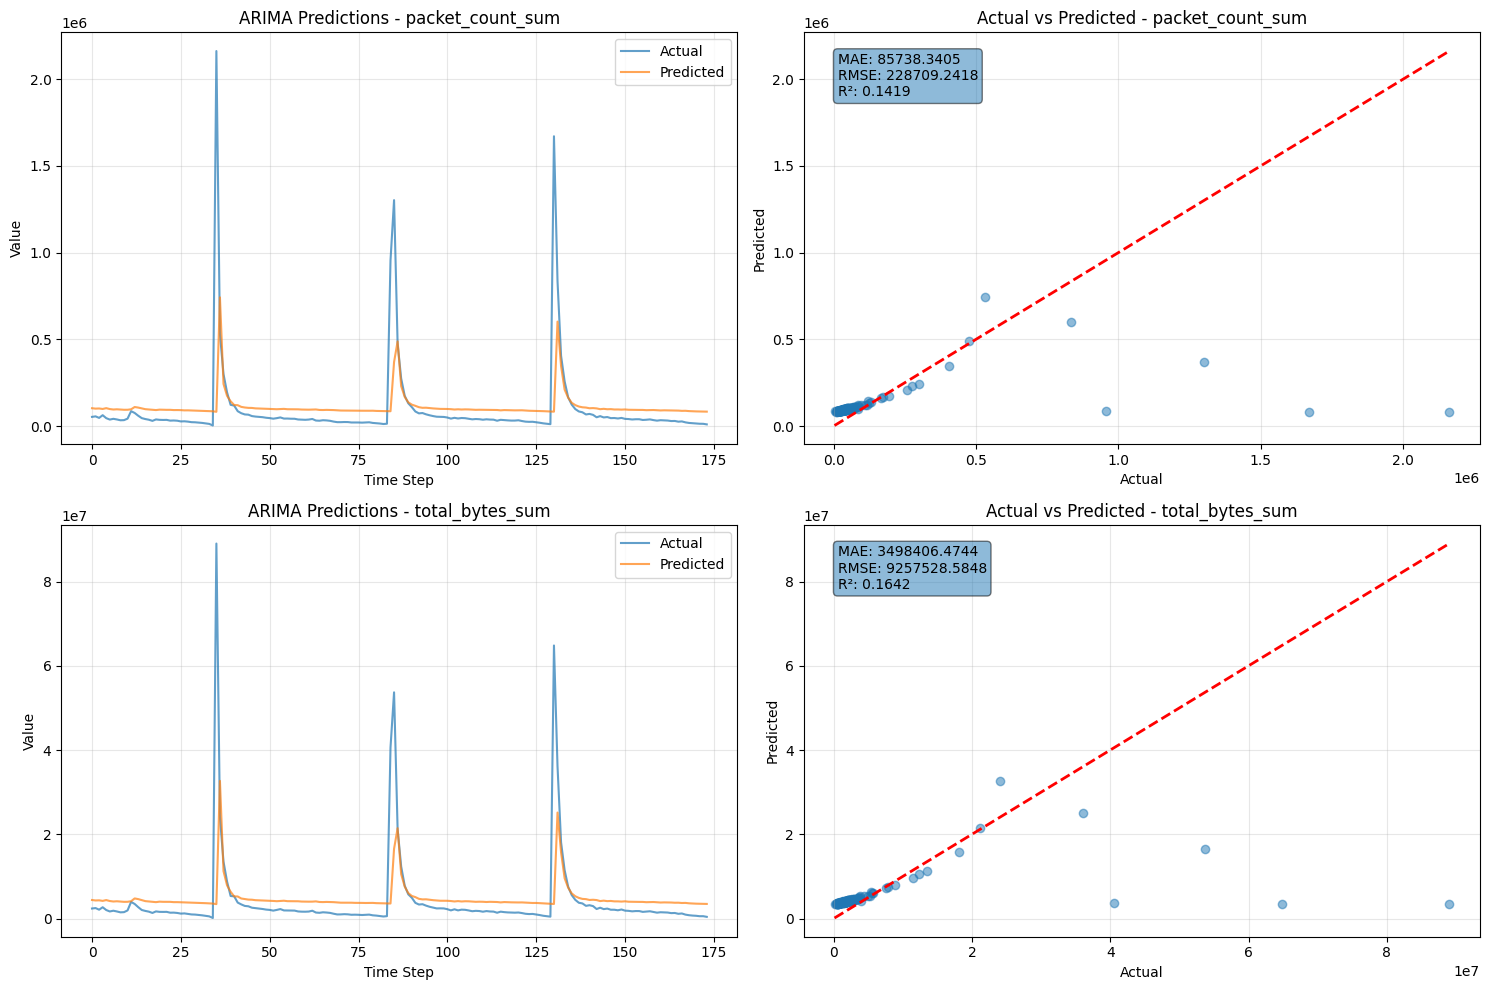

2025-08-28 20:19:52,867 - INFO - Plot saved to ..\code\data\jupyter\baseline_results\lstm_results_10s.png


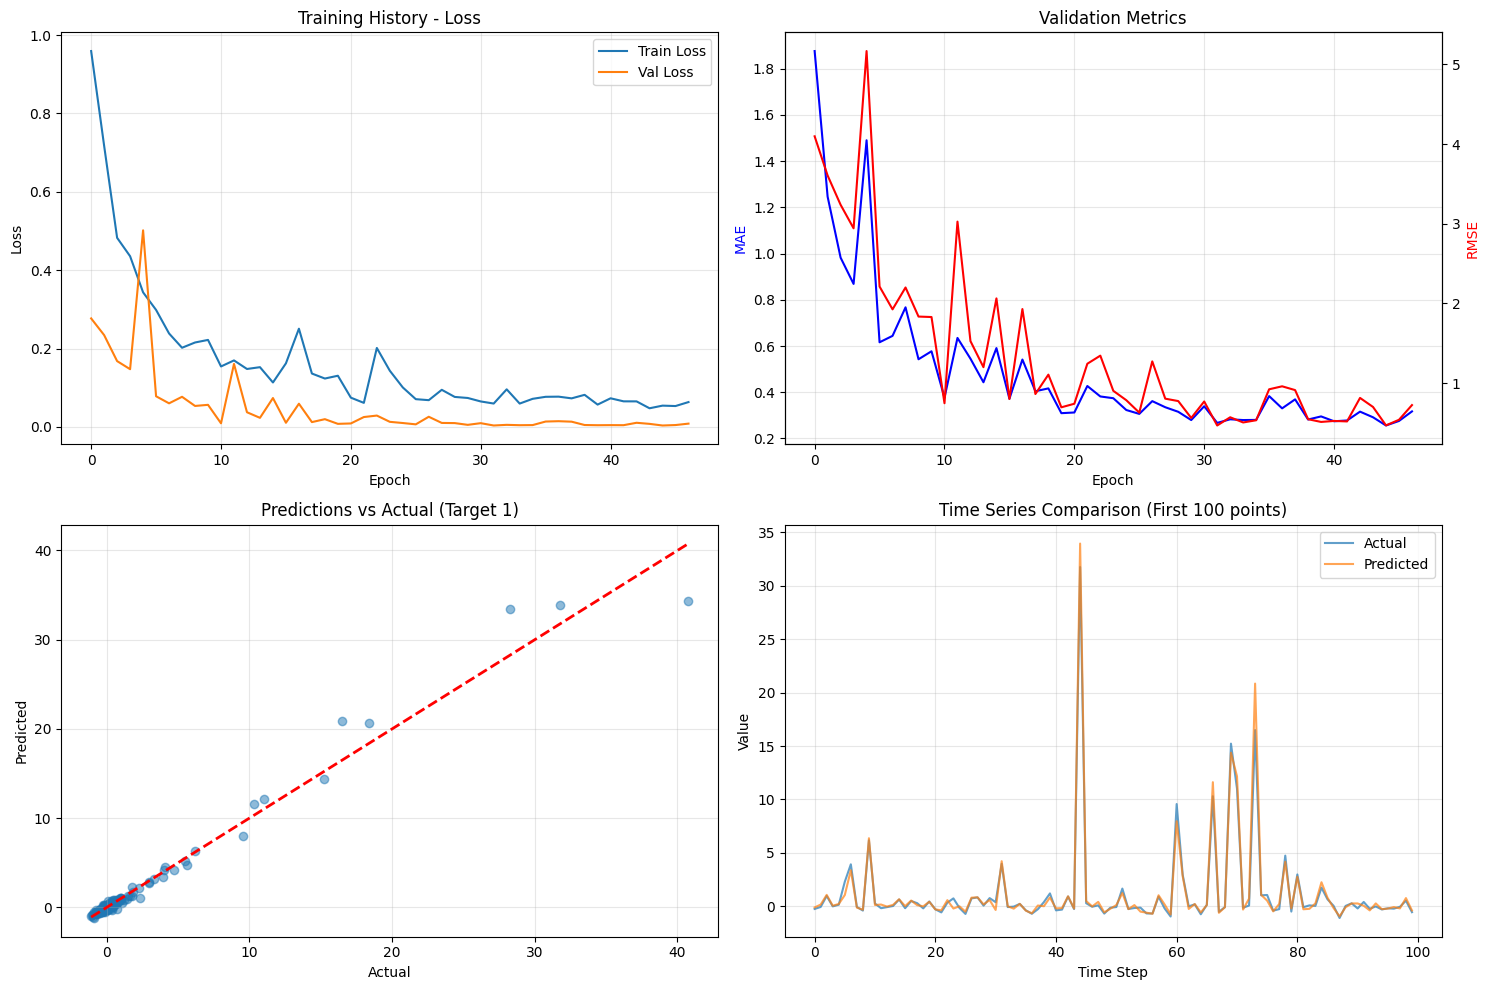

2025-08-28 20:19:53,120 - INFO - Model saved to ..\code\data\jupyter\baseline_results\10s\lstm_model.pt
2025-08-28 20:19:53,120 - INFO - Results saved to ..\code\data\jupyter\baseline_results\10s
2025-08-28 20:19:53,120 - INFO - 
2025-08-28 20:19:53,121 - INFO - PROCESSING 30S WINDOW
2025-08-28 20:19:53,121 - INFO - ================================================================================
2025-08-28 20:19:53,121 - INFO - ================================================================================
2025-08-28 20:19:53,121 - INFO - BASELINE MODEL COMPARISON
2025-08-28 20:19:53,122 - INFO - ================================================================================
2025-08-28 20:19:53,155 - INFO - Selected LSTM file: lstm_data.npz (287 sequences)
2025-08-28 20:19:53,156 - INFO - 
2025-08-28 20:19:53,156 - INFO - Running ARIMA Baseline
2025-08-28 20:19:53,156 - INFO - ============================================================
2025-08-28 20:19:53,157 - INFO - ==============

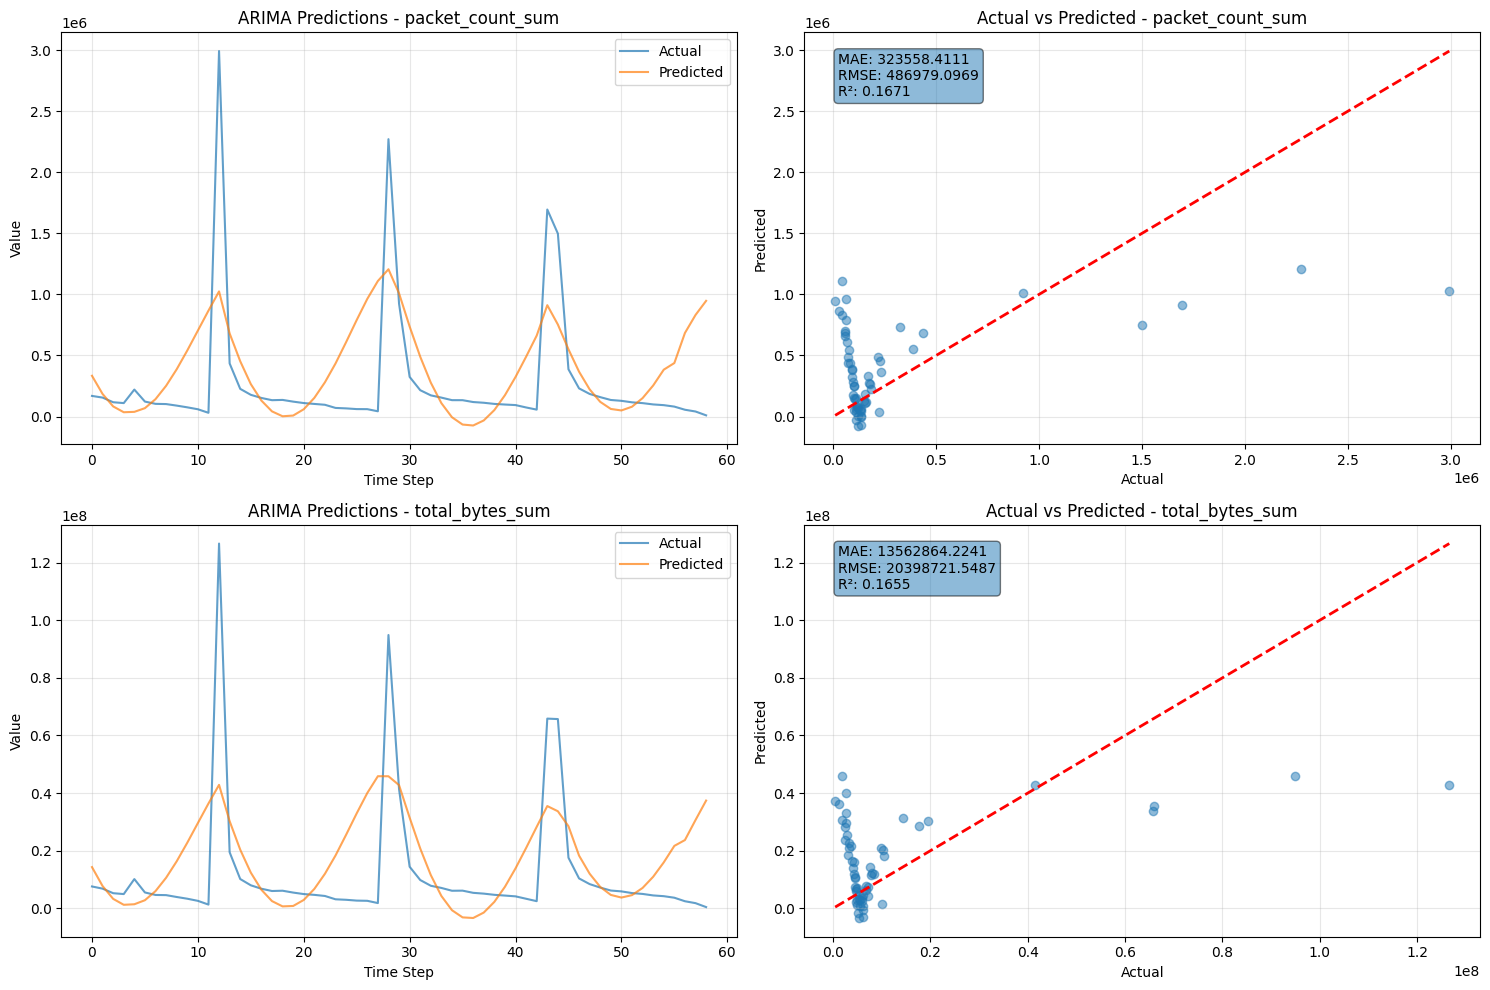

2025-08-28 20:20:13,514 - INFO - Plot saved to ..\code\data\jupyter\baseline_results\lstm_results_30s.png


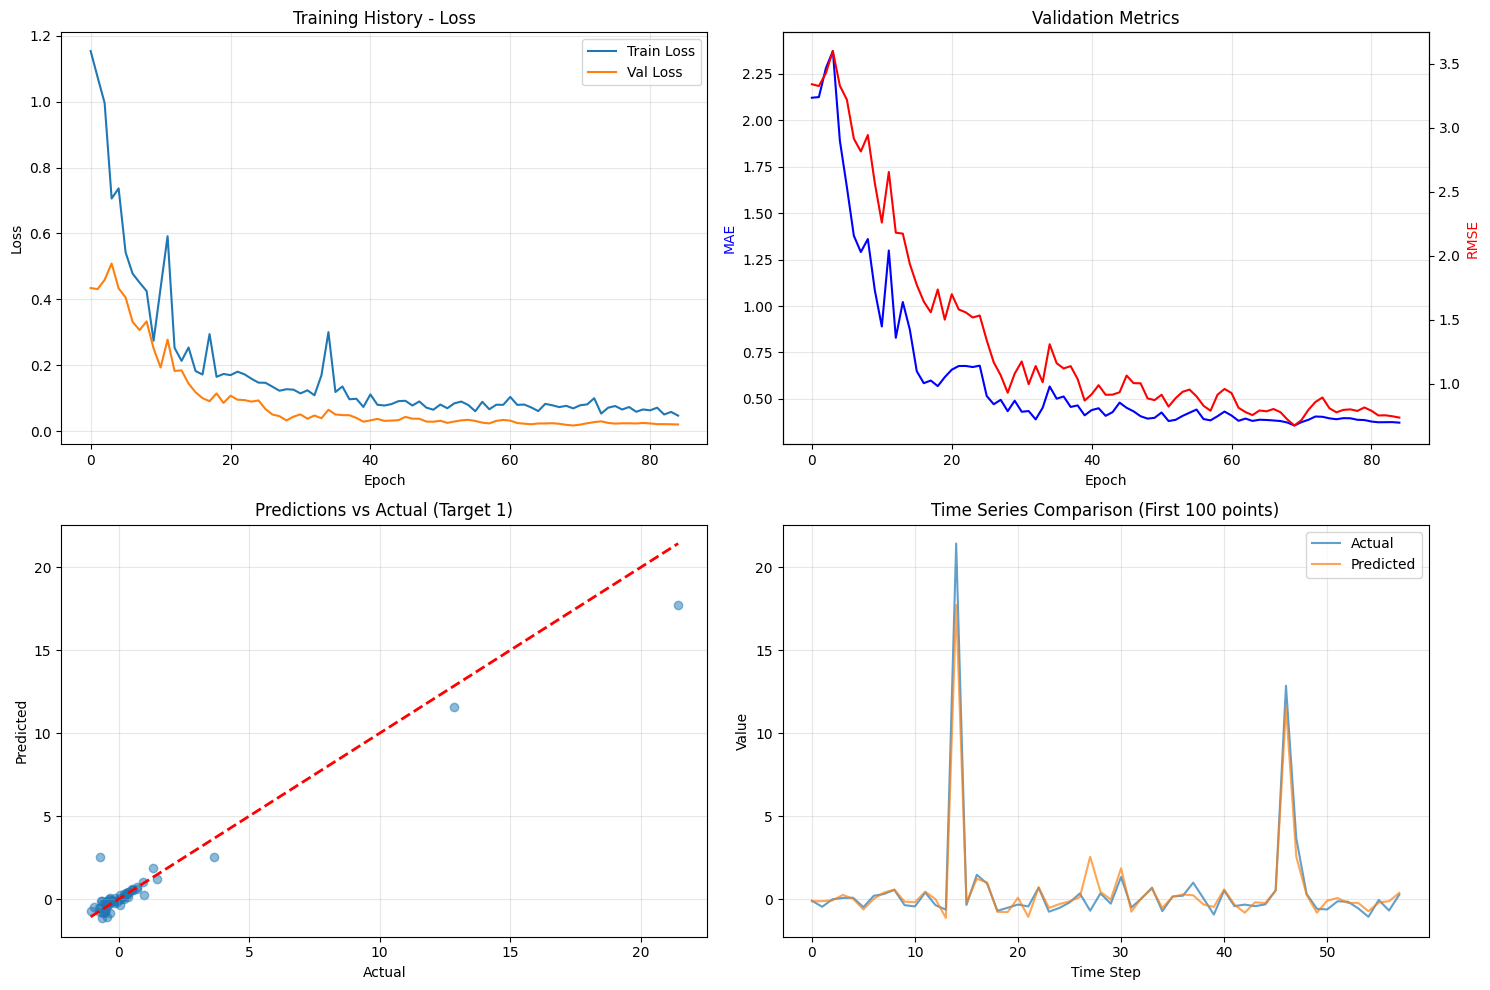

2025-08-28 20:20:13,787 - INFO - Model saved to ..\code\data\jupyter\baseline_results\30s\lstm_model.pt
2025-08-28 20:20:13,787 - INFO - Results saved to ..\code\data\jupyter\baseline_results\30s
2025-08-28 20:20:13,787 - INFO - 
2025-08-28 20:20:13,787 - INFO - PROCESSING 1MIN WINDOW
2025-08-28 20:20:13,787 - INFO - ================================================================================
2025-08-28 20:20:13,787 - INFO - ================================================================================
2025-08-28 20:20:13,787 - INFO - BASELINE MODEL COMPARISON
2025-08-28 20:20:13,787 - INFO - ================================================================================
2025-08-28 20:20:13,817 - INFO - Selected LSTM file: lstm_data.npz (142 sequences)
2025-08-28 20:20:13,817 - INFO - 
2025-08-28 20:20:13,817 - INFO - Running ARIMA Baseline
2025-08-28 20:20:13,817 - INFO - ============================================================
2025-08-28 20:20:13,817 - INFO - =============

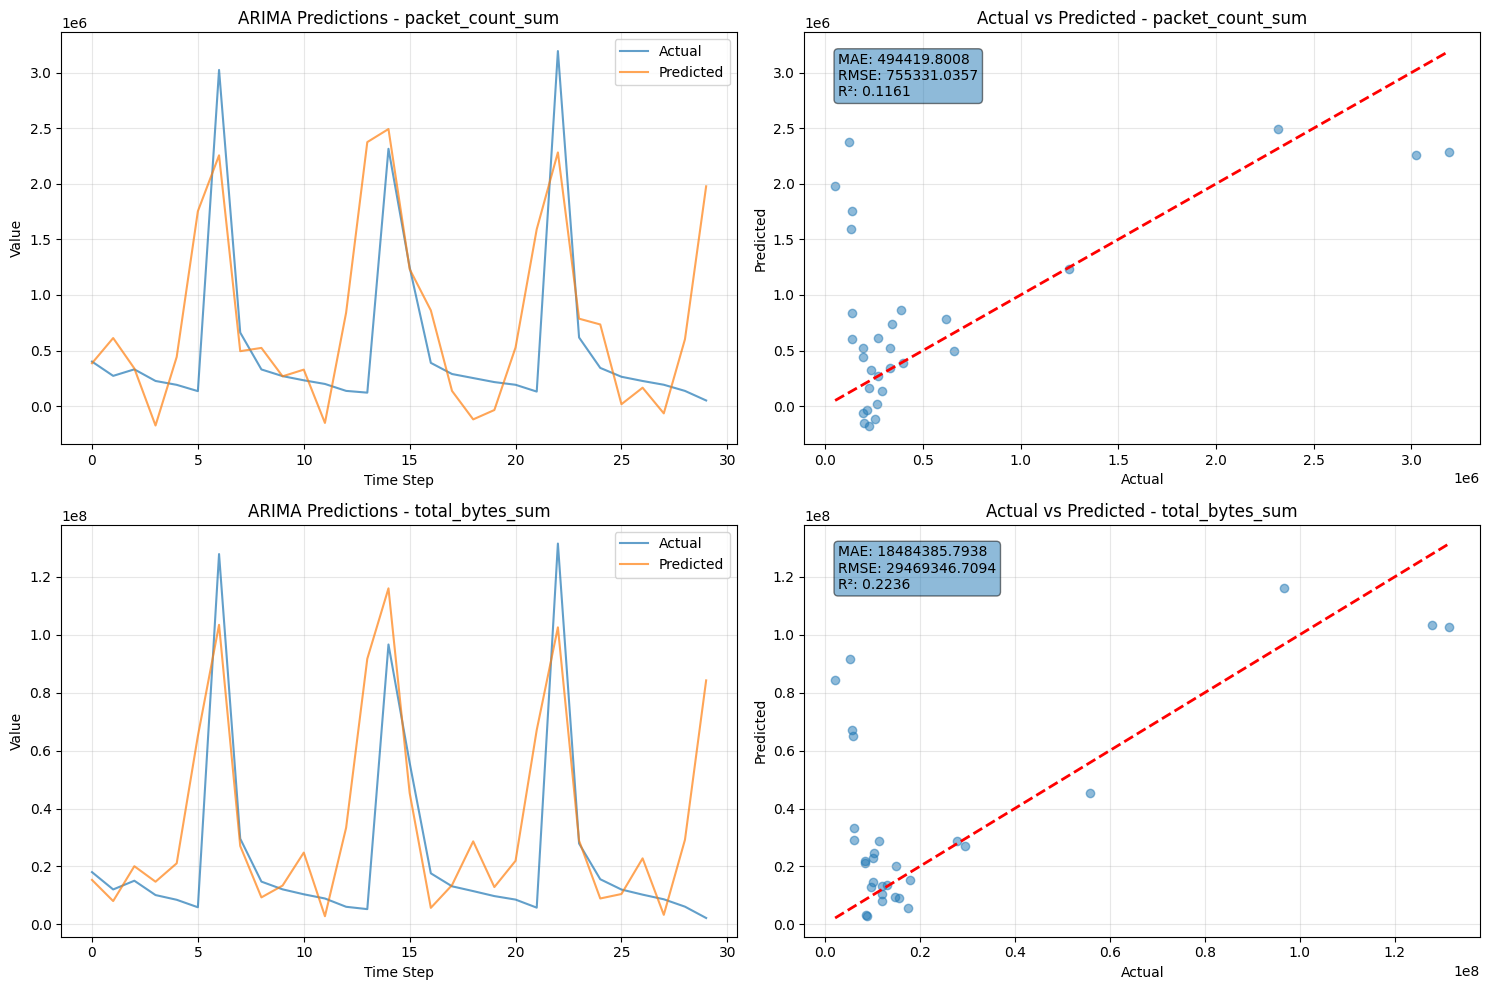

2025-08-28 20:20:34,316 - INFO - Plot saved to ..\code\data\jupyter\baseline_results\lstm_results_1min.png


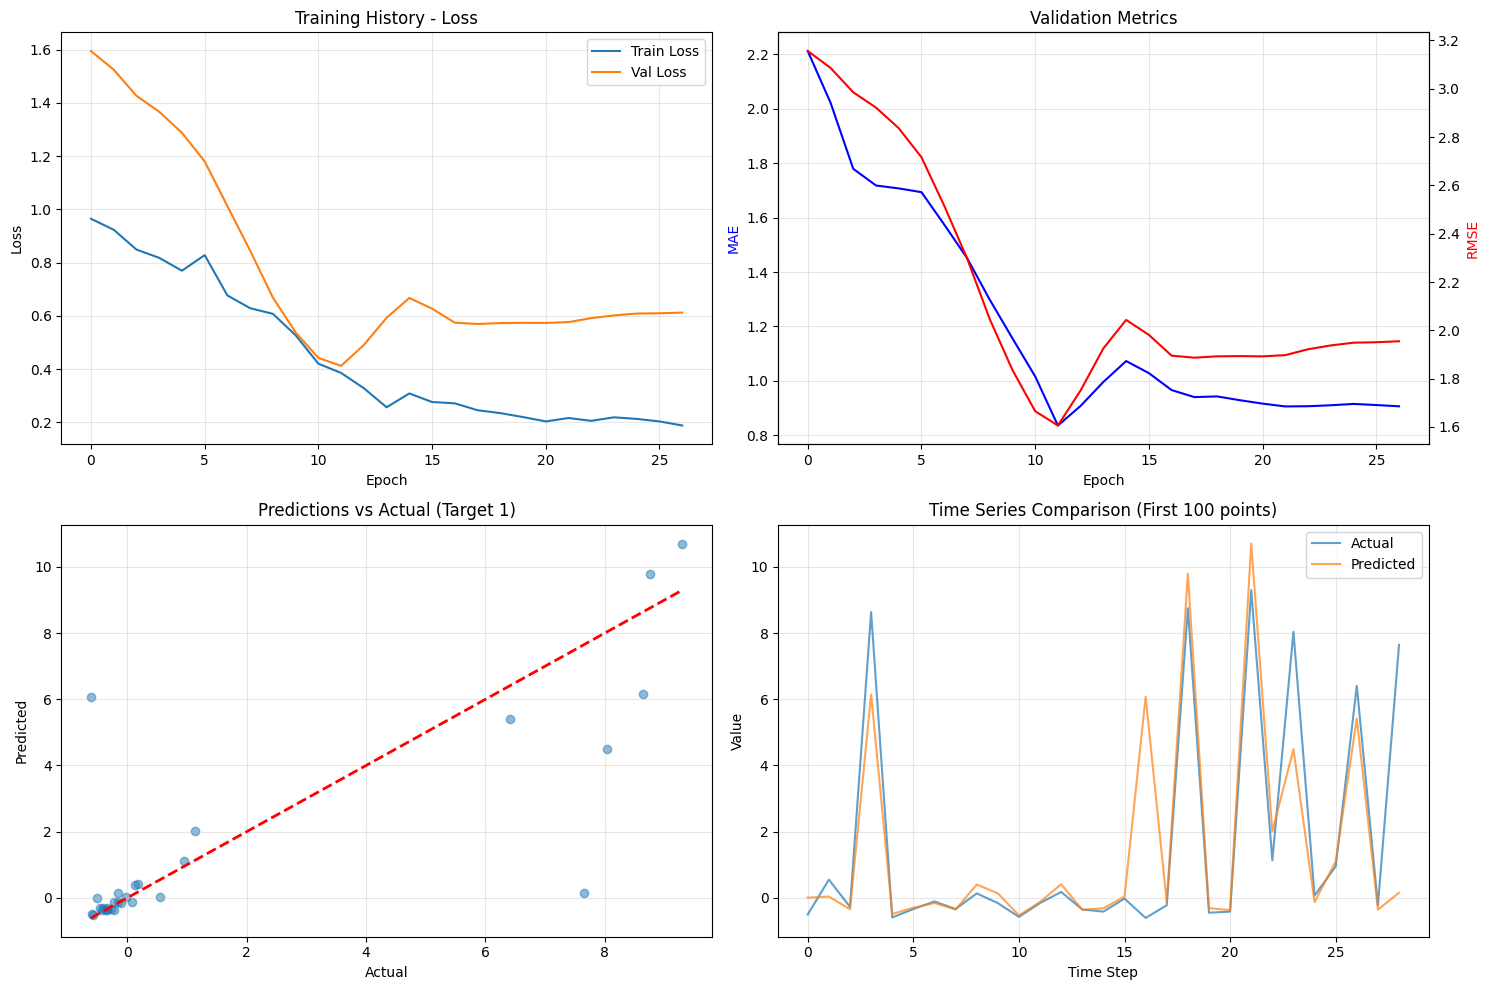

2025-08-28 20:20:34,602 - INFO - Model saved to ..\code\data\jupyter\baseline_results\1min\lstm_model.pt
2025-08-28 20:20:34,602 - INFO - Results saved to ..\code\data\jupyter\baseline_results\1min
2025-08-28 20:20:34,602 - INFO - 
2025-08-28 20:20:34,602 - INFO - FINAL SUMMARY - ALL TIME WINDOWS
2025-08-28 20:20:34,602 - INFO - ================================================================================
2025-08-28 20:20:34,602 - INFO - 
                       mae          rmse        r2  train_time  \
window model                                                     
10s    arima  1.792072e+06  4.743119e+06  0.153084    0.033908   
       lstm   3.170594e-01  7.251400e-01  0.977509    2.903190   
30s    arima  6.943211e+06  1.044285e+07  0.166324    0.263463   
       lstm   3.716671e-01  7.366371e-01  0.945640    1.689513   
1min   arima  9.489403e+06  1.511234e+07  0.169829    0.480440   
       lstm   9.063043e-01  1.954739e+00  0.621364    0.386176   

              inference_t

In [7]:
if __name__ == "__main__":
    main()